# Proyecto Final

El operador de telecomunicaciones Interconnect le gustaría poder pronosticar su tasa de cancelación de clientes. Si se descubre que un usuario o usuaria planea irse, se le ofrecerán códigos promocionales y opciones de planes especiales. El equipo de marketing de Interconnect ha recopilado algunos de los datos personales de sus clientes, incluyendo información sobre sus planes y contratos.

## Interconnect proporciona principalmente dos tipos de servicios:

1. Comunicación por teléfono fijo. El teléfono se puede conectar a varias líneas de manera simultánea.
2. Internet. La red se puede configurar a través de una línea telefónica (DSL, *línea de abonado digital*) o a través de un cable de fibra óptica.

#### Algunos otros servicios que ofrece la empresa incluyen:

- Seguridad en Internet: software antivirus (*ProtecciónDeDispositivo*) y un bloqueador de sitios web maliciosos (*SeguridadEnLínea*).
- Una línea de soporte técnico (*SoporteTécnico*).
- Almacenamiento de archivos en la nube y backup de datos (*BackupOnline*).
- Streaming de TV (*StreamingTV*) y directorio de películas (*StreamingPelículas*)

La clientela puede elegir entre un pago mensual o firmar un contrato de 1 o 2 años. Puede utilizar varios métodos de pago y recibir una factura electrónica después de una transacción.

En este caso como el cliente solicita poder pronosticar su tasa de cancelación de clientes el modelo de pronóstico a utilizar es de **Clasificación**, para ello se deben crear varios modelos que se puedan comparar y así elegir el mejor.

Para la evaluación de los modelos, la métrica a utilizar es el valor de AUC-ROC (Área bajo la curva - Característica Operativa del Receptor) lo que permitirá comparar los diferentes modelos en el mismo plano. El modelo que tenga la 'curva hacia arriba y a la izquierda' es el ganador.

Como métrica adicional se usará la exactitud.

## Tabla de contenido


1. Plan de trabajo
2. Inicialización y Preprocesamiento de datos
3. Análisis exploratorio de datos (EDA)
4. Entrenamiento y evaluación de modelos
5. Función para evaluar modelos
 - Modelo de Regresión Logística
 - Modelo de Árbol de Clasificación
 - Modelo Bosque Aleatorio para Clasificación
 - Modelo CatBoostClassifier
 - Modelo LightGBMClassifier
6. Comparación de los resultados de los modelos
7. Conclusiones

## 1. Plan de Trabajo

i. Inicialización y preprocesamiento de datos
- vista previa: Identificación de los tipos de datos, valores nulos y duplicados
- preprocesamiento: Realizar limpieza (imputación nde valores faltantes o eliminación de registros ruidosos)

ii. Análisis exploratorio de datos (EDA)
- unión de datasets
- transformar variables categoricas en numéricas según lo requiera el modelo a trabajar.
- Incluir la correlación de datos y descartar variables que aporten información redundante.
  
iii. Entrenar distintos modelos predictivos con los datos
- Ajuste de hiperparámetros
- Segmentación de datos: separar los conjuntos de entrenamiento y prueba, cuidar que el conjunto de entrenamiento tenga datos de contratos cancelados
- Entrenamiento multimodelo: Prueba de los diferentes modelos

iv. Evaluación de modelos
- métrica principal para la evaluación de los modelos el valor de AUC-ROC: La cual es idonea para problemas de clasificación binaria como este caso, ya que mide la capacidad del modelo para distinguir entre las clases independientemente del umbral.
- métrica secundaria la exactitud (accuracy): La cual es útil como referencia general, sin embargo debe ser interpretada con cuidado si los datos están muy desbalanceados.

v. Comparar los resultados de los modelos y entender su comportamiento.

vi. Conclusiones

## 2. Inicialización y Preprocesamiento de datos

### Información Proporcionada

Los datos consisten en archivos obtenidos de diferentes fuentes:

- `contract.csv` — información del contrato;
- `personal.csv` — datos personales del cliente;
- `internet.csv` — información sobre los servicios de Internet;
- `phone.csv` — información sobre los servicios telefónicos.

En cada archivo, la columna `customerID` (ID de cliente) contiene un código único asignado a cada cliente. La información del contrato es válida a partir del 1 de febrero de 2020.


In [47]:
# Importar librerias
# Librerías para manipulación de datos
import pandas as pd
from pandas.api.types import is_numeric_dtype
import numpy as np

# Librerías de visualización de gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de modelos 
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score

from catboost import CatBoostClassifier, Pool
from lightgbm import LGBMClassifier

In [48]:
# Importación de datos
#df_contract = pd.read_csv('/datasets/contract.csv', parse_dates = [1])
#df_personal = pd.read_csv('/datasets/personal.csv')
#df_internet = pd.read_csv('/datasets/internet.csv')
#df_phone = pd.read_csv('/datasets/phone.csv')

In [49]:
# Importación de datos
df_contract = pd.read_csv(r'C:\Users\Joha\Documents\Diana\Capacitaciones\Tripletren\18._Sprint 18\Proyecto\final_provider\final_provider\contract.csv', parse_dates = [1])
df_personal = pd.read_csv(r'C:\Users\Joha\Documents\Diana\Capacitaciones\Tripletren\18._Sprint 18\Proyecto\final_provider\final_provider\personal.csv')
df_internet = pd.read_csv(r'C:\Users\Joha\Documents\Diana\Capacitaciones\Tripletren\18._Sprint 18\Proyecto\final_provider\final_provider\internet.csv')
df_phone = pd.read_csv(r'C:\Users\Joha\Documents\Diana\Capacitaciones\Tripletren\18._Sprint 18\Proyecto\final_provider\final_provider\phone.csv')

In [50]:
# Examinar los tamaños de los datasets
for df in [df_contract, df_personal, df_internet, df_phone]:
    print(f'Tamaño del dataset: {df.shape}')

Tamaño del dataset: (7043, 8)
Tamaño del dataset: (7043, 5)
Tamaño del dataset: (5517, 8)
Tamaño del dataset: (6361, 2)


In [51]:
# Visualización de la información que contienen
display('Dataset información del contrato:', df_contract.head())
display('Dataset datos personales del cliente:',  df_personal.head()) 
display('Dataset de servicios de internet', df_internet.head())
display('Dataset sobre servicios telefónicos', df_phone.head())

'Dataset información del contrato:'

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


'Dataset datos personales del cliente:'

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


'Dataset de servicios de internet'

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


'Dataset sobre servicios telefónicos'

,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


In [52]:
# Visualización de la información que contienen
print('Dataset información del contrato:')
print(df_contract.info())
print('Dataset datos personales del cliente:')
print(df_personal.info())
print('Dataset de servicios de internet:')
print(df_internet.info())
print('Dataset sobre servicios telefónicos:')
print(df_phone.info())

Dataset información del contrato:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   object        
 1   BeginDate         7043 non-null   datetime64[ns]
 2   EndDate           7043 non-null   object        
 3   Type              7043 non-null   object        
 4   PaperlessBilling  7043 non-null   object        
 5   PaymentMethod     7043 non-null   object        
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7043 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 440.3+ KB
None
Dataset datos personales del cliente:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   custome

Se puede observar que no hay datos ausentes en ninguno de los datasets.

In [53]:
# Verificación de valores duplicados
df_contract.duplicated().sum(), df_personal.duplicated().sum(), df_internet.duplicated().sum(), df_phone.duplicated().sum()

(np.int64(0), np.int64(0), np.int64(0), np.int64(0))

## 3. Preprocesamiento de datos (EDA)

### 3.1 Unión de datasets

In [54]:
# Unión de los datasets
df = df_contract.merge(df_personal, on='customerID', how='left') \
                .merge(df_internet, on='customerID', how='left') \
                .merge(df_phone, on='customerID', how='left')

display('Dataset con la unión de 4 datasets anteriores:', df.head())

'Dataset con la unión de 4 datasets anteriores:'

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No


In [55]:
# Cambio de la columna TotalCharges de tipo object a float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   object        
 1   BeginDate         7043 non-null   datetime64[ns]
 2   EndDate           7043 non-null   object        
 3   Type              7043 non-null   object        
 4   PaperlessBilling  7043 non-null   object        
 5   PaymentMethod     7043 non-null   object        
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7032 non-null   float64       
 8   gender            7043 non-null   object        
 9   SeniorCitizen     7043 non-null   int64         
 10  Partner           7043 non-null   object        
 11  Dependents        7043 non-null   object        
 12  InternetService   5517 non-null   object        
 13  OnlineSecurity    5517 non-null   object        
 14  OnlineBackup      5517 n

In [57]:
# Exploración de valores nulos en la columna TotalCharges
df[df['TotalCharges'].isnull()]

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
488,4472-LVYGI,2020-02-01,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,Female,0,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,No,NaN
753,3115-CZMZD,2020-02-01,No,Two year,No,Mailed check,20.25,NaN,Male,0,No,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
936,5709-LVOEQ,2020-02-01,No,Two year,No,Mailed check,80.85,NaN,Female,0,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,Yes,No
1082,4367-NUYAO,2020-02-01,No,Two year,No,Mailed check,25.75,NaN,Male,0,Yes,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes
1340,1371-DWPAZ,2020-02-01,No,Two year,No,Credit card (automatic),56.05,NaN,Female,0,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,No,NaN
3331,7644-OMVMY,2020-02-01,No,Two year,No,Mailed check,19.85,NaN,Male,0,Yes,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
3826,3213-VVOLG,2020-02-01,No,Two year,No,Mailed check,25.35,NaN,Male,0,Yes,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes
4380,2520-SGTTA,2020-02-01,No,Two year,No,Mailed check,20.00,NaN,Female,0,Yes,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
5218,2923-ARZLG,2020-02-01,No,One year,Yes,Mailed check,19.70,NaN,Male,0,Yes,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
6670,4075-WKNIU,2020-02-01,No,Two year,No,Mailed check,73.35,NaN,Female,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Yes


In [58]:
df['BeginDate'].describe()

count                             7043
mean     2017-04-30 13:01:50.918642688
min                2013-10-01 00:00:00
25%                2015-06-01 00:00:00
50%                2017-09-01 00:00:00
75%                2019-04-01 00:00:00
max                2020-02-01 00:00:00
Name: BeginDate, dtype: object

Al realizar la unión de las tablas aparecen valores nulos, esto puede presentarse debido a que no todos los clientes cuentan con todos los servicios ofrecidos por la empresa y en el caso de la columna `TotalCharges`, la aparición de valores nulos puede deberse a que hay clientes nuevos que aún no han realizado el pago de su primera factura, ya que la fecha máxima que tiene el dataset en la columna `BeginDate` es el 2020-02-01, que es la fecha que aparece para los valores nulos.

Para el caso de las otras columnas con valores nulos estos se reemplazan por la palabra **'No'**, ya que es muy probable que el cliente no cuente con este servicio.

In [59]:
# Comprobar que las fechas estén en orden cronológico
df['BeginDate'].is_monotonic_increasing

False

In [60]:
# Ordenar el dataset por la columna BeginDate
df = df.sort_values(by='BeginDate').reset_index(drop=True)

In [61]:
# Información de los clientes que han cancelado el servicio
end_date = df[df['EndDate'] != 'No'].copy()
end_date['EndDate'] = pd.to_datetime(end_date['EndDate'], errors='coerce')

print(f"Valores nulos creados por error: {df['EndDate'].isna().sum()}")

Valores nulos creados por error: 0


In [62]:
# Descripción de las personas que han cancelado el servicio
end_date['EndDate'].describe()

count                             1869
mean     2019-11-15 21:31:18.009630720
min                2019-10-01 00:00:00
25%                2019-11-01 00:00:00
50%                2019-11-01 00:00:00
75%                2019-12-01 00:00:00
max                2020-01-01 00:00:00
Name: EndDate, dtype: object

La fecha de inicio de los contratos fue el 1 de octubre de 2013 y la información suministrada está actualizada hasta el 1 de fecbrero de 2020.
Al revisar las fechas de cancelación de contrato por parte de los clientes la primera fecha de cancelación fue el 1 de octubre de 2019 y la última fecha fue el 1 de febrero de 2020

Aunque ambas columnas tienen una cantidad de datos significativa, no se consideran actualmente una característica irrelevante para el modelo, ya que a partir de la información de la fecha de terminación se generó la columna *target*.

In [63]:
# Reemplazo de valores nulos
# Reemplazo de los valores nulos de la columna TotalCharges por 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Reemplazo de valores nulos de las columnas de tipo object por 'No'
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna('No')

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   object        
 1   BeginDate         7043 non-null   datetime64[ns]
 2   EndDate           7043 non-null   object        
 3   Type              7043 non-null   object        
 4   PaperlessBilling  7043 non-null   object        
 5   PaymentMethod     7043 non-null   object        
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7043 non-null   float64       
 8   gender            7043 non-null   object        
 9   SeniorCitizen     7043 non-null   int64         
 10  Partner           7043 non-null   object        
 11  Dependents        7043 non-null   object        
 12  InternetService   7043 non-null   object        
 13  OnlineSecurity    7043 non-null   object        
 14  OnlineBackup      7043 n

Se crea la columna objetivo a partir de la columna *`EndDate`*, por lo tanto esta última no puede ser tenida en cuenta para la construcción del modelo.

In [65]:
# Crear columna objetivo de predicción
df['target'] = (df['EndDate'] != 'No').astype(int)
display(df.head())
print(df['target'].value_counts())

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,...,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines,target
0,8580-QVLOC,2013-10-01,2019-10-01 00:00:00,Two year,No,Credit card (automatic),92.45,6440.25,Female,1,...,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Yes,1
1,2889-FPWRM,2013-10-01,2019-10-01 00:00:00,One year,Yes,Bank transfer (automatic),117.80,8684.80,Male,0,...,No,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Yes,1
2,0917-EZOLA,2013-10-01,2019-10-01 00:00:00,Two year,Yes,Bank transfer (automatic),104.15,7689.95,Male,1,...,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Yes,1
3,2834-JRTUA,2013-11-01,2019-10-01 00:00:00,Two year,Yes,Electronic check,108.05,7532.15,Male,0,...,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Yes,1
4,7317-GGVPB,2013-11-01,2019-10-01 00:00:00,Two year,Yes,Credit card (automatic),108.60,7690.90,Male,0,...,No,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,Yes,1


target
0    5174
1    1869
Name: count, dtype: int64


Al crear la columna `target` con base en los datos de la `EndDate` se obtiene como resultado que 5174 clientes continuan con sus contratos, mientras 1869 se han retirado. Esta información será la que permitirá realizar la predicción de los posibles clientes que continuarán o no con la suscripción se sus servicios con la empresa Interconnect.

In [66]:
# Exploración de valores columnas Categóricas
cat_col = ['Type', 'PaymentMethod', 'InternetService', 'gender']
for col in cat_col:
    print(f'Valores únicos en la columna {col}: {df[col].unique()}')
    print()   

Valores únicos en la columna Type: ['Two year' 'One year' 'Month-to-month']

Valores únicos en la columna PaymentMethod: ['Credit card (automatic)' 'Bank transfer (automatic)' 'Electronic check'
 'Mailed check']

Valores únicos en la columna InternetService: ['DSL' 'Fiber optic' 'No']

Valores únicos en la columna gender: ['Female' 'Male']



In [67]:
# Análisis exploratorio de datos - Variables categóricas
df.describe(include='object')[['Dependents', 'PaperlessBilling', 'Partner', 'OnlineSecurity', 'OnlineBackup', 
                               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']]

,Dependents,PaperlessBilling,Partner,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,2,2,2,2,2,2,2,2,2,2
top,No,Yes,No,No,No,No,No,No,No,No
freq,4933,4171,3641,5024,4614,4621,4999,4336,4311,4072


### 3.2 Transformación de variables

In [68]:
# Transformación de variables categóricas a numéricas
# Columnas tipo objet con valores 'Yes' y 'No' a 1 y 0 respectivamente
binary_cols = ['Dependents', 'PaperlessBilling', 'Partner', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 
               'StreamingMovies', 'MultipleLines']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Columnas tipo object con más de 2 categorías a variables dummy
columns = ['Type', 'PaymentMethod', 'InternetService']
df = pd.get_dummies(df, columns=columns, drop_first=True, dtype=int)

# Columna gender
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

display(df.head())

,customerID,BeginDate,EndDate,PaperlessBilling,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,...,StreamingMovies,MultipleLines,target,Type_One year,Type_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
0,8580-QVLOC,2013-10-01,2019-10-01 00:00:00,0,92.45,6440.25,0,1,1,1,...,1,1,1,0,1,1,0,0,0,0
1,2889-FPWRM,2013-10-01,2019-10-01 00:00:00,1,117.80,8684.80,1,0,1,0,...,1,1,1,1,0,0,0,0,1,0
2,0917-EZOLA,2013-10-01,2019-10-01 00:00:00,1,104.15,7689.95,1,1,1,0,...,1,1,1,0,1,0,0,0,1,0
3,2834-JRTUA,2013-11-01,2019-10-01 00:00:00,1,108.05,7532.15,1,0,0,0,...,1,1,1,0,1,0,1,0,1,0
4,7317-GGVPB,2013-11-01,2019-10-01 00:00:00,1,108.60,7690.90,1,0,1,0,...,1,1,1,0,1,1,0,0,1,0


In [69]:
# Reemplazo de espacios en los nombres de las columnas por guiones bajos
df.columns = df.columns.str.replace(' ', '_')

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   customerID                             7043 non-null   object        
 1   BeginDate                              7043 non-null   datetime64[ns]
 2   EndDate                                7043 non-null   object        
 3   PaperlessBilling                       7043 non-null   int64         
 4   MonthlyCharges                         7043 non-null   float64       
 5   TotalCharges                           7043 non-null   float64       
 6   gender                                 7043 non-null   int64         
 7   SeniorCitizen                          7043 non-null   int64         
 8   Partner                                7043 non-null   int64         
 9   Dependents                             7043 non-null   int64   

### 3.3 Correlación de variables

In [71]:
# Revisión de variables numéricas
df[['MonthlyCharges', 'TotalCharges']].describe()

,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000
mean,64.761692,2279.734304
std,30.090047,2266.794470
min,18.250000,0.000000
25%,35.500000,398.550000
50%,70.350000,1394.550000
75%,89.850000,3786.600000
max,118.750000,8684.800000


Correlación entre variables numéricas y la variable objetivo:


,MonthlyCharges,TotalCharges,target
MonthlyCharges,1.000000,0.651174,0.193356
TotalCharges,0.651174,1.000000,-0.198324
target,0.193356,-0.198324,1.000000


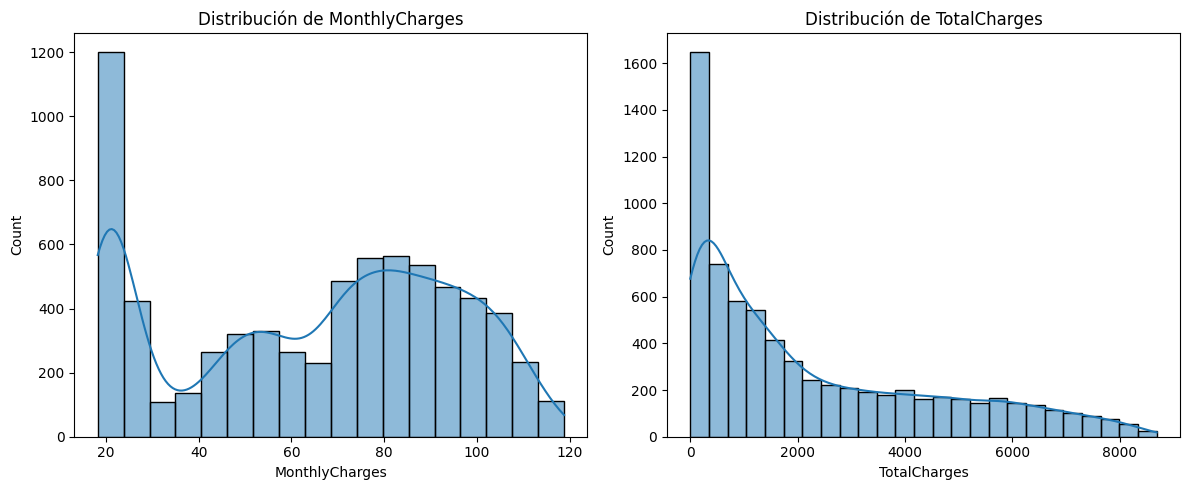

In [72]:
# Correlación entre variables numéricas y la variable objetivo
numeric_cols = ['MonthlyCharges', 'TotalCharges']  

df_corr = df[numeric_cols + ['target']].corr()  
print('Correlación entre variables numéricas y la variable objetivo:')
display(df_corr) 

# Histogramas de las variables numéricas
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['MonthlyCharges'], kde=True)
plt.title('Distribución de MonthlyCharges')
plt.subplot(1, 2, 2)
sns.histplot(df['TotalCharges'], kde=True)
plt.title('Distribución de TotalCharges')
plt.tight_layout()
plt.show()

Al revisar los resultados de los histogramas, see puede concluir lo siguiente:

***Distribución de MonthlyCharges***
- Los clientes que realizan pagos de montos menores a 30 USD son los que mayor riesgo presentan a la hora de cancelar el servicio, estos clientes suelen ser los que tienen servicios básicos contratados. 

- Los siguientes clientes con riesgo de cancelación son los clientes entre 70 y 100 USD esto puede presentar debido a si encuentran otra empresa que les ofrezca un mejor precio por los productos contratados.

***Distribución de TotalCharges***
- Los clientes de mayor riesgo de cancelación son los que tienen un valor  menor a 2000 USD, lo que indica que muchos clientes son nuevos pues su valor acumulado historico es cercano a 0.
- Los clientes que han pagado más de 4000 USD son los clientes fidelizados.

,Dependents,PaperlessBilling,Partner,SeniorCitizen,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines,PaymentMethod_Credit_card_(automatic),PaymentMethod_Electronic_check,PaymentMethod_Mailed_check,Type_One_year,Type_Two_year
0,70.041176,40.778078,51.69672,83.785319,71.333239,65.511856,65.611245,70.978276,61.564674,61.209712,57.816271,78.389891,66.420559,77.112026,79.085617,75.933551
1,29.958824,59.221922,48.30328,16.214681,28.666761,34.488144,34.388755,29.021724,38.435326,38.790288,42.183729,21.610109,33.579441,22.887974,20.914383,24.066449


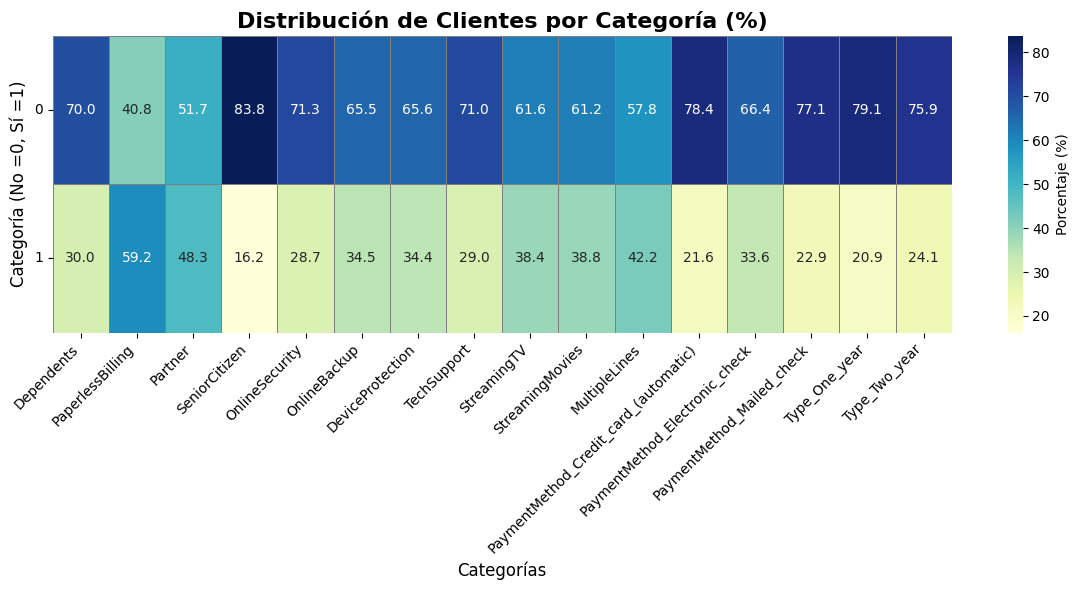

In [73]:
# Exploración de clientes que han cancelado el servicio
bool_col = ['Dependents', 'PaperlessBilling', 'Partner', 'SeniorCitizen', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 
            'StreamingTV', 'StreamingMovies', 'MultipleLines', 'PaymentMethod_Credit_card_(automatic)',	
            'PaymentMethod_Electronic_check','PaymentMethod_Mailed_check','Type_One_year','Type_Two_year']

summary = []

for col in bool_col:
    stats = df[col].value_counts(normalize=True) * 100
    summary.append(stats)

table = pd.concat(summary, axis=1)
table.columns = bool_col
display(table)

plt.figure(figsize=(12, 6))
sns.heatmap(table, annot=True, cmap='YlGnBu', fmt='.1f', cbar_kws={'label': 'Porcentaje (%)'}, linewidths=0.5, linecolor='gray')

plt.title('Distribución de Clientes por Categoría (%)', fontsize=16, fontweight='bold')
plt.xlabel('Categorías', fontsize=12)
plt.ylabel('Categoría (No =0, Sí =1)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.grid(False)

plt.tight_layout()
plt.show()

Al revisar el impacto que tiene la cancelación de los contratos por categoría se observa lo siguiente:

- Los clientes con mayores porcentajes de cancelación de sus contratos son: los que tienen factura electrónica (PaperlessBilling) el 59.2%, la siguiente categoría es los clientes que tienen socios (partner) con un 48,3%, la categoría de multiples líneas (MultipleLines) con un 42.2% y el pago por cheque electrónico (PaymentMethod_Electronic check) 33.6%. 
- Las categorías StreamingTV, StreamingMovie, OnlineBackup y DeviceProtection también presentan porcentajes altos de cancelación, sin embargo no todos los clientes cuentan con estos servicios.
- Los porcentajes de cancelación más bajos esta en la categoría *Type_Two year*  y *Type_One year*, donde se tiene la mayor cantidad de personas fieles a la empresa, 75,9% y 79,1% respectivamente. 

Lo anterior nos permite tener una perspectiva sobre los  clientes con los que cuenta la empresa y oportunidades de mejora.

In [74]:
# Diferencia entre clientes que han cancelado el servicio y los que no lo han hecho
desequilibrio = (table.loc[0] - table.loc[1]).abs()

# Filtrado de variables con mayor desequilibrio
desequilibrio_filtrado = desequilibrio[desequilibrio > 60]

print('Variables con mayor desequilibrio entre clientes que han cancelado el servicio y los que no lo han hecho:')
display(desequilibrio_filtrado.sort_values(ascending=False))

Variables con mayor desequilibrio entre clientes que han cancelado el servicio y los que no lo han hecho:


SeniorCitizen    67.570638
dtype: float64

Al revisar la diferencia entre los clientes que han cancelado el servicio y los que continuan con el, la variable que presenta mayor desequilibrio es `SeniorCitizen`, lo que refleja que la mayor parte de la población que contrata el servicio de telecomunicaciones es la población joven. Por lo tanto a esta variable no se le aplicará ninguna técnica de balanceo, puesto que estaría indicando al modelo que hay proporcionalidad entre la población joven y los adultos mayores, lo que sería una situación ficticia y generaría errores en el modelo a la hora de evaluar la realidad del mercado.

## 4. Entrenamiento de modelos

### 4.1 Preparación conjunto de datos y segmentación

Se eliminan las columnas que no son relevantes para el entrenamiento del modelo como las columnas `customer`, `gender`que no muestran influencia en el objetivo y la columna `EndDate` que forma parte de la característica objetivo.


In [75]:
# Eliminar columnas innecesarias, definir variables caracteristicas y objetivo
X = df.drop(columns=['customerID', 'BeginDate', 'EndDate', 'gender', 'target'], axis=1) # Features
y = df['target'] # Target

Escalamiento de las columnas `MonthlyCharges` y `TotalCharges`

In [76]:
# Escalamiento 
num_cols = ['MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

In [77]:
# Verificación del escalamiento de las variables numéricas
display(X[num_cols].describe())

,MonthlyCharges,TotalCharges
count,7.043000e+03,7.043000e+03
mean,-6.456728e-17,-1.291346e-16
std,1.000071e+00,1.000071e+00
min,-1.545860e+00,-1.005780e+00
25%,-9.725399e-01,-8.299464e-01
50%,1.857327e-01,-3.905282e-01
75%,8.338335e-01,6.648034e-01
max,1.794352e+00,2.825806e+00


In [78]:
# Separación de los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

--- Diagnóstico de Balanceo de Clases ---
Clase 0 (Leales): 5174 clientes (73.46%)
Clase 1 (Cancelados) : 1869 clientes (26.54%)
Relación de desbalance: 1 a 2
----------------------------------------


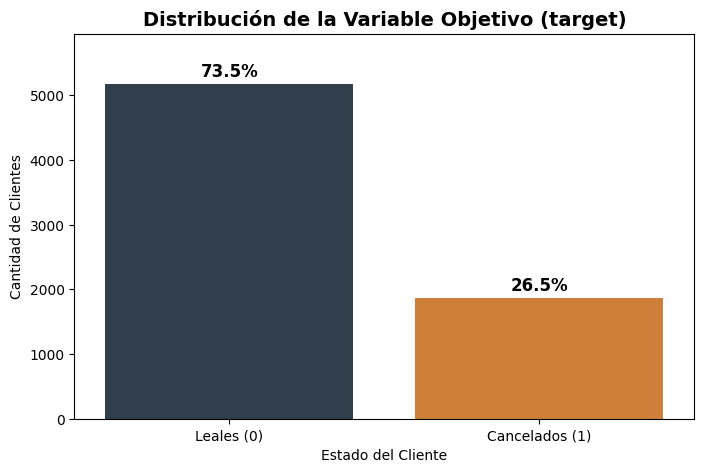

Variables con muy baja variabilidad (Posible Sesgo):
Ninguna variable detectada con sesgo extremo.


In [79]:
# Revisión del balanceo de los datos
# 1. Cálculo de frecuencias
counts = y.value_counts()
percentages = y.value_counts(normalize=True) * 100

# 2. Reporte de resultados
print("--- Diagnóstico de Balanceo de Clases ---")
print(f"Clase 0 (Leales): {counts[0]} clientes ({percentages[0]:.2f}%)")
print(f"Clase 1 (Cancelados) : {counts[1]} clientes ({percentages[1]:.2f}%)")
print(f"Relación de desbalance: 1 a {int(counts[0]/counts[1])}")
print("-" * 40)

# 3. Visualización
plt.figure(figsize=(8, 5))
colors = ['#2c3e50', '#e67e22']

ax = sns.barplot(x=counts.index, y=counts.values, palette=colors, hue=counts.index, legend=False)

# Añadir etiquetas de porcentaje sobre las barras
for i, p in enumerate(ax.patches):
    ax.annotate(f'{percentages.iloc[i]:.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), 
                textcoords='offset points', fontsize=12, fontweight='bold')

plt.title('Distribución de la Variable Objetivo (target)', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Leales (0)', 'Cancelados (1)'])
plt.ylabel('Cantidad de Clientes')
plt.xlabel('Estado del Cliente')
plt.ylim(0, counts.max() * 1.15)
plt.show()

# Revisar si hay variables casi constantes en X
print("Variables con muy baja variabilidad (Posible Sesgo):")
low_variance = [col for col in X.columns if X[col].value_counts(normalize=True).iloc[0] > 0.95]
print(low_variance if low_variance else "Ninguna variable detectada con sesgo extremo.")

## 5. Función para evaluación multimodelo

Modelo               | AUC-ROC (Test) 
----------------------------------------
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000784 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 546
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

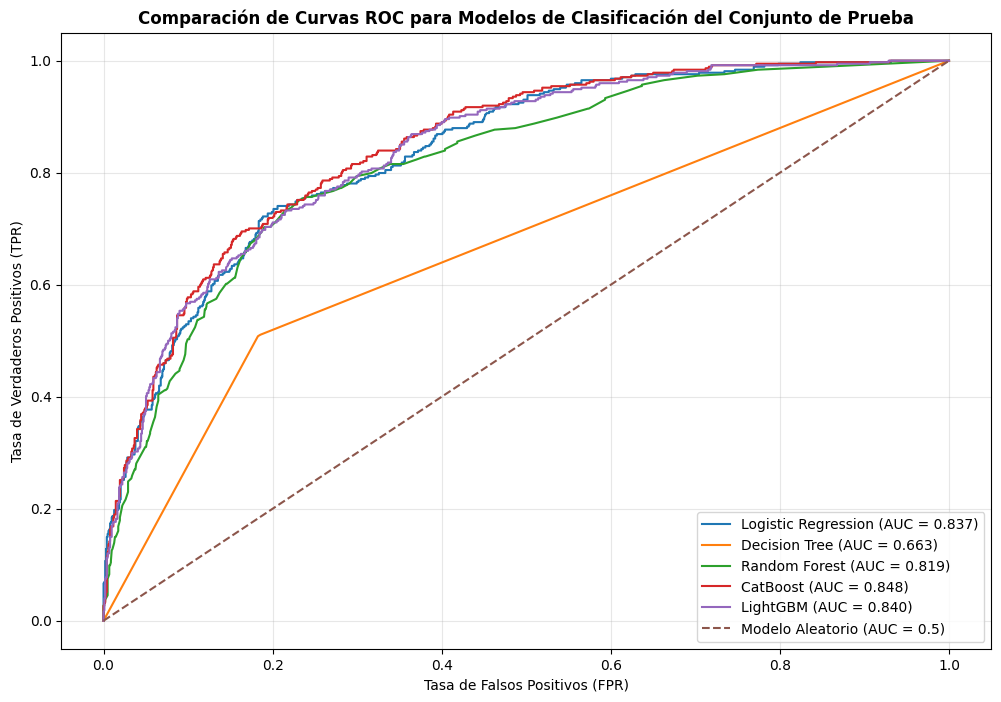

In [80]:
# Definición de modelos a evaluar con pesos balanceados
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'CatBoost': CatBoostClassifier(random_state=42, depth=4, verbose=0),
    'LightGBM': LGBMClassifier(random_state=42, class_weight='balanced', num_leaves=25, max_depth=6)
}

# Bucle para entrenar y visualización
plt.figure(figsize=(12, 8))

print(f"{'Modelo':<20} | {'AUC-ROC (Test)':<15}")
print("-" * 40)

for name, model in models.items():
    # Entrenamiento del modelo
    model.fit(X_train, y_train)
    
    # Probabilidades de predicción para la clase positiva
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Cálculo del AUC-ROC
    auc_score = roc_auc_score(y_test, y_pred_proba)
    
    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')
    
plt.plot([0, 1], [0, 1], linestyle='--', label='Modelo Aleatorio (AUC = 0.5)')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Comparación de Curvas ROC para Modelos de Clasificación del Conjunto de Prueba', fontsize=12, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

## 6. Comparación resultados de los modelos

In [81]:
# Comparación de métricas de rendimiento entre modelos
results_list = []

for name, model in models.items():
    # 1. Entrenamiento
    model.fit(X_train, y_train)
    
    # 2. Predicciones para Entrenamiento
    train_probs = model.predict_proba(X_train)[:, 1]
    train_preds = model.predict(X_train)
    
    # 3. Predicciones para Prueba
    test_probs = model.predict_proba(X_test)[:, 1]
    test_preds = model.predict(X_test)
    
    # 4. Cálculo de métricas
    train_auc = roc_auc_score(y_train, train_probs)
    test_auc = roc_auc_score(y_test, test_probs)
    
    train_acc = accuracy_score(y_train, train_preds)
    test_acc = accuracy_score(y_test, test_preds)
    
    # 5. Guardar en la lista
    results_list.append({
        'Modelo': name,
        'AUC-ROC Train': train_auc,
        'AUC-ROC Test': test_auc,
        'Accuracy Train': train_acc,
        'Accuracy Test': test_acc,
        'Diferencia AUC': abs(train_auc - test_auc)
    })

# Crear DataFrame de resultados
df_results = pd.DataFrame(results_list)

# Dar formato la tabla para mejor lectura
display(df_results.sort_values(by='AUC-ROC Test', ascending=False).style.background_gradient(cmap='YlGnBu'))

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000371 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 546
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

,Modelo,AUC-ROC Train,AUC-ROC Test,Accuracy Train,Accuracy Test,Diferencia AUC
3,CatBoost,0.888288,0.848115,0.830848,0.813343,0.040172
4,LightGBM,0.920059,0.840177,0.819134,0.750177,0.079883
0,Logistic Regression,0.841479,0.837384,0.747781,0.726757,0.004095
2,Random Forest,0.999742,0.818850,0.996805,0.794180,0.180893
1,Decision Tree,0.999979,0.663089,0.996450,0.733854,0.336891


## 7. Conclusiones

Al revisar los resultados obtenidos en las métricas por modelo se concluye lo siguiente:

- El modelo con el mejor resultado en el conjunto de prueba fue Catboost con un valor de 84.81%. Esto indica que el modelo tiene una capacidad del 84.81% de distinguir entre cual cliente se irá y cuál se quedará. Y el valor del accuracy en este mismo conjunto de datos fue del 81.33% lo que reafirma los resultados de la metrica AUC-ROC a la hora de evaluar la capacidad que tiene este modelo en sus predicciones. Adicionalmente la diferencia AUC (0.040) es menor del 0.1 lo que indica que el modelo es confiable.

- El modelo con menor diferencia de AUC es el de Regresión Logística cuyo valor es 0.004095, lo que nos indica que es el modelo más estable pues se comportará de la misma manera con los datos que ya conoce (conjunto de entrenamiento valor de AUC-ROC = 84.15%) respecto a nuevos datos (conjunto de prueba valor de AUC-ROC = 83.74%)

- Los modelos de RandomForest y Decision Tree tienen como resultado valores cercanos a 1, lo que indica que estos modelos presentan sobreajuste (overfitting), esto quiere decir que el modelo no aprendió patrones generales para identificar a los posibles clientes que se quedarán o se van, sino que memorizo los datos.

- En el caso del modelo LightGBM es el segundo modelo con mejor desempeño, con una diferencia AUC de 0.079, una capacidad de 84.01% de identificar cuando se quedará o irá un cliente un accuracy de 75.02%.

Lista de Control de los criterios solicitados en el código de solución:

- [x] Realizaste todos los pasos
- [x] La solución coincide con la condición de la tarea
- [x] El modelo se extreno y probó correctamente
- [x] Se tiene la puntuación de calidad del mejor modelo
- [x] Se mantuvo la estructura del proyecto
- [x] Se manttuvo el código limpio

### Informe de solución

- ¿Qué pasos del plan se realizaron y qué pasos se omitieron (Explica por qué)?

**Rta:** Los pasos del plan que se realizaron son:

i. Inicialización y preprocesamiento de datos
- vista previa: Identificación de los tipos de datos, valores nulos y duplicados
- preprocesamiento: Realizar limpieza (imputación nde valores faltantes o eliminación de registros ruidosos)

ii. Análisis exploratorio de datos (EDA)
- unión de datasets
- transformar variables categoricas en numéricas según lo requiera el modelo a trabajar.
- Incluir la correlación de datos y descartar variables que aporten información redundante.
  
iii. Entrenar distintos modelos predictivos con los datos
- Ajuste de hiperparámetros
- Segmentación de datos: separar los conjuntos de entrenamiento y prueba, cuidar que el conjunto de entrenamiento tenga datos de contratos cancelados
- Entrenamiento multimodelo: Prueba de los diferentes modelos

iv. Evaluación de modelos
- métrica principal para la evaluación de los modelos el valor de AUC-ROC: La cual es idonea para problemas de clasificación binaria como este caso, ya que mide la capacidad del modelo para distinguir entre las clases independientemente del umbral.
- métrica secundaria la exactitud (accuracy): La cual es útil como referencia general, sin embargo debe ser interpretada con cuidado si los datos están muy desbalanceados.

v. Comparar los resultados de los modelos y entender su comportamiento.

vi. Conclusiones

El paso que omití fue el balanceo de los datos por fuera de los modelos, ya que en la revisión del desbalance de estos el resultado fue que la relación de desbalance fue 1 a 2 y ninguna variable de detecto con sesgo extremo, por ello se incluyo dentro de los modelos el parámetro `class_weight='balanced'`

- ¿Qué dificultades encontraste y cómo lograste resolverlas?

**Rta:** Las dificultades encontradas fueron:

- Definir con que información reemplazar los valores ausentes después de realizar la unión de los datasets, evaluar lo que representaban estos valores y su impacto a la hora de evaluar el modelo lo cual resolví con la exploración de los datos y con la función describe() que me ayudo mucho a definir cual era la mejor opción para reemplazar la información faltante.

- ¿Cuáles fueron algunos de los pasos claves para resolver la tarea?

**Rta:** Los pasos claves que utilicé para resolver la tarea fue revisar el orden utilizado en el desarrollo de proyectos anteriores y lo indicado en el documento Guía de CRISP-DM de IBM SPSS Modeler para la mineria de datos.

- ¿Cuál es tu modelo final y que calidad tiene?

**Rta:** Mi modelo final es Catboost el cual tiene una calidad de 84.73% de predicción a la hora de indicar si un cliente se queda o se va. Adicionalmente la diferencia del AUC fue de 4.26% lo que indica que el modelo es confiable.